# Accessible Data Visualization

### Flattening the Curve -- Activity

In what ways is this visualization inaccesible?
- Small fonts
- Gray shadow is very subtle (why is grey area hihglighted?)


## Government of Canada guidelines for accessible data
- Make information clear, concise and easy to use
- Present information in predictable, barrier-free ways
- Provide barrier-free ways for people to interact with you
- Make sure technology-based products work with assistive technologies and devices



## Colour

- Three channels -> Lumincance, Saturation and Hue
- Can use a colour blindness simulator to see how it will be perceived by colour blind people
- Viridis is a package in R (and python) used to make plots easier to read by colourblind people

## Text

- Fonts should be at least 12 point in size

## Alt-text

- alt-text consists of a description of the image; if there is text in the image, alt-text should include the text

### Alt-text activity

What is appropriate alt-text for this image?
- Two scientists in discussion in front of a fume hood
- Alt-text can depend on intended purpose of an image

## Four Types of Descriptive Content
1:
 - Focus on chart elements such as chart type, title, axis ranges, labels, colours
 2:
 - Descriptive statistics (eg. mean), outliers, max and min points, correlations, comparing points
 3:
 - Complex trends, pattern synthesis, clusters, exceptions, common concepts
 - Perceptual interpretations of the data
 4:
 - Context and domain insights, social and political context and explanations
 - Subjective interpretations that go beyond the data

### Activity: 
- 1: Axis is time of the day
- 2: Average time on each category
- 3: How many hours they spend on creative work
- 4: People's daily routines based on country they live in


# Subplots and Combining Visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

/var/folders/l4/q8rfbq1j34xbkm9jpzth656c0000gn/T/ipykernel_48878/2658473223.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


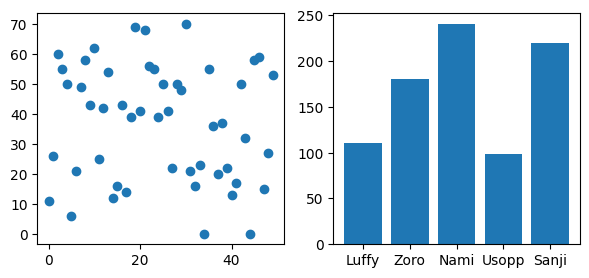

In [2]:
# Creating two plots next to eachother 
# Previously would be fig, ax = plt.subplots(figsize=(5, 3))
fig,(ax1, ax2) = plt.subplots(ncols=2,
                        nrows=1,
                        figsize=(7, 3))
ax1.scatter(x1,y1)
ax2.bar(x2,y2)
fig.show()

/var/folders/l4/q8rfbq1j34xbkm9jpzth656c0000gn/T/ipykernel_48878/1535855325.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


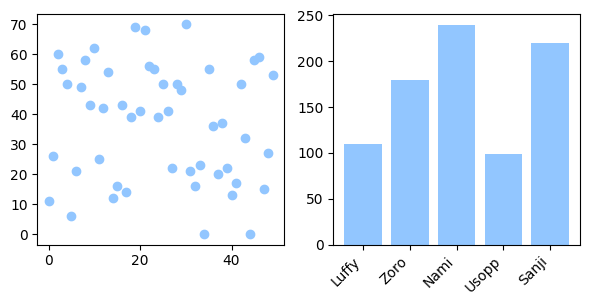

In [5]:
## Activity: Customizing plots
plt.style.use('seaborn-v0_8-pastel') 
fig,(ax1, ax2) = plt.subplots(ncols=2,
                        nrows=1,
                        figsize=(7, 3))
ax1.scatter(x1,y1)
ax2.bar(x2,y2)
# Rotate x axis labels
plt.xticks(rotation=45, ha='right')
fig.show()

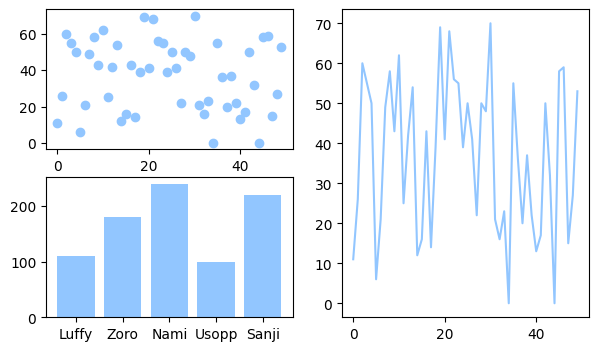

In [ ]:
# Subplots without a grid arrangement
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4))
#Fill with data
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
plt.show()

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

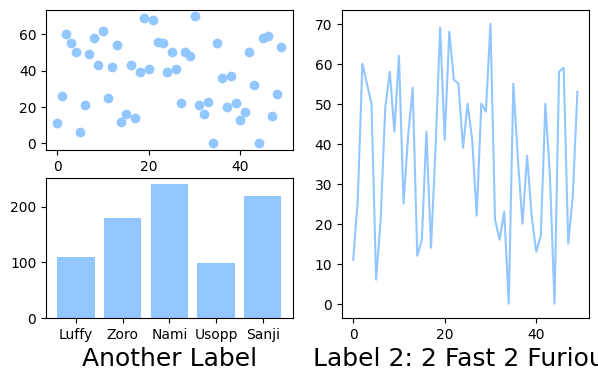

In [ ]:
#Adding axis labels
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4)) 
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18 ) #Gets cut off

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

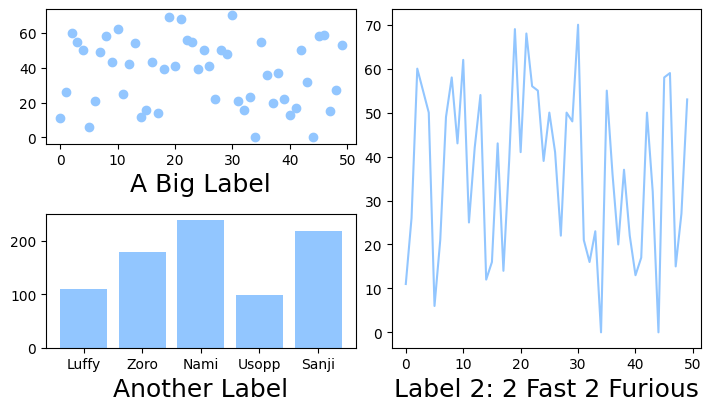

In [ ]:
# Constrain layout
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                                figsize=(7, 4),
                                layout = "constrained") #Makes it so our label doesnt get cut off
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)
someaxes["ax1"].set_xlabel('A Big Label', fontsize=18)
someaxes["ax2"].set_xlabel('Another Label', fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious', fontsize=18)

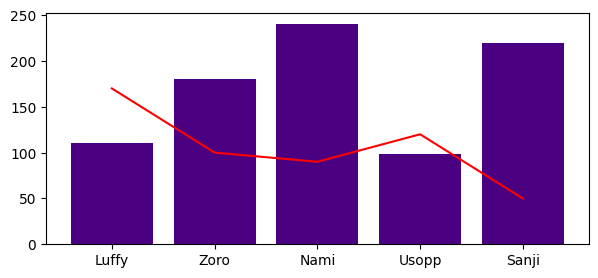

In [10]:
#Creating mutliple vizualizations in one figure
# first make our sample data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])
# define our figure and axes (just one this time)
fig, ax = plt.subplots(figsize=(7, 3))
# now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1,
color = "indigo")
ax.plot(x, y2,
color = "red")

<ErrorbarContainer object of 3 artists>

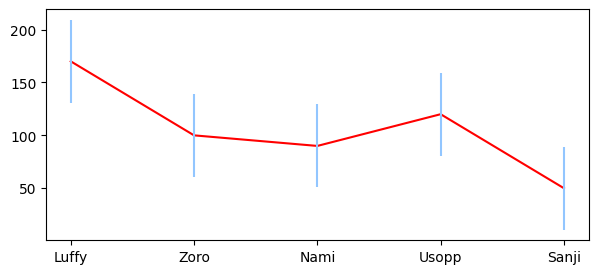

In [ ]:
#Adding errorbars
y2_sd = np.std(y2) #Calculate the standard deviation of our y2 values
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")
ax.errorbar(x, #our x values
        y2, #our y values
        yerr = y2_sd,
        fmt = "none")

<ErrorbarContainer object of 3 artists>

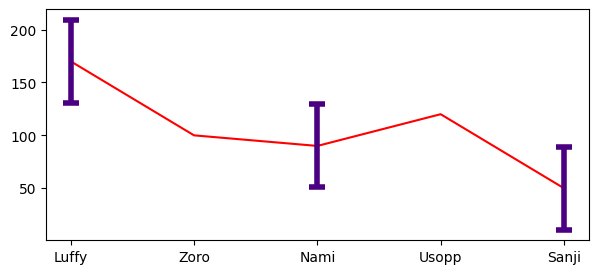

In [ ]:
#Customizing appearance of errorbars
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2,
        color = "red")
ax.errorbar(x,
        y2,
        yerr = y2_sd,
        fmt = "none",
        ecolor= "indigo", #Color
        elinewidth= 4,
        capsize = 6,
        capthick= 4,
        errorevery= 2) #Errorevery controls how many errorbars are shown. 2 means every other point will have an errorbar

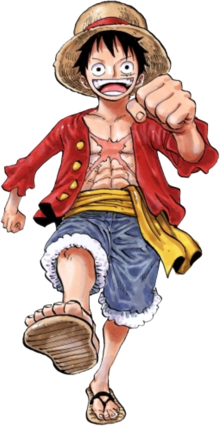

In [21]:
# Adding images to a plot

# import necessary packages
from PIL import Image # to open images
import requests # to get images from URLs
from io import BytesIO # to store images

# Get image from internet
url = "https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png"
headers = {"User-Agent": "Mozilla/5.0","Accept": "image/*,*/*;q=0.8","Referer": "https://en.wikipedia.org/"}
response = requests.get(url, headers=headers)
image_file = BytesIO(response.content)
image = Image.open(image_file)
image

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

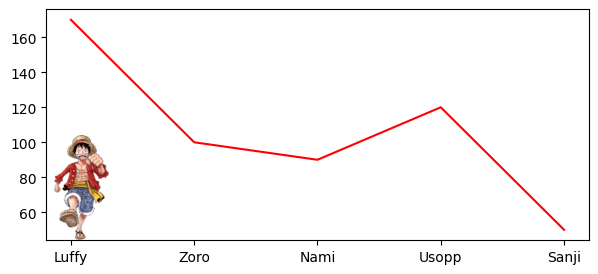

In [22]:
#Make line plot (same as before)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

#Overlay new axis (image)
ax_image = fig.add_axes([0.1, # x coordinate (ON FIGURE, NOT AXES)
                        0.11, # y coordinate (ON FIGURE, NOT AXES)
                        0.15, # image width
                        0.35]) # image height

#Use imshow
ax_image.imshow(image)
ax_image.axis('off')

In [20]:
# Saving plots
path = '/Users/darahvlaminck/Desktop'
# can be full path or relative path
filename = '/fig1a.png'
plt.savefig(path+filename, dpi=300)
# note that path shouldn't end with / since filename starts with it

<Figure size 640x480 with 0 Axes>